In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import math
import time
import pandas as pd
import os,shutil,random
from sklearn.model_selection import train_test_split
from PIL import Image, ImageEnhance, ImageFilter
import torch.nn as nn
from sklearn.metrics import precision_recall_curve, auc
from torch.nn.utils import clip_grad_norm_
import random
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from sklearn.model_selection import train_test_split
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import torchvision.models as models
from torch.utils.data import DataLoader, TensorDataset  
from torch.cuda.amp import autocast, GradScaler      
import kagglehub
from tqdm import tqdm
import torch.nn.utils.spectral_norm as spectral_norm
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

/data5/home/wriddhiraajd/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")
print("Path to dataset files:", path)
root = os.path.join(path, "tiny-imagenet-200")

Path to dataset files: /data5/home/wriddhiraajd/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1


In [3]:
val_dir = os.path.join(root, "val")
img_dir = os.path.join(val_dir, "images")
ann = os.path.join(val_dir, "val_annotations.txt")

if os.path.exists(img_dir):
    with open(ann) as f:
        for line in f:
            img, cls = line.strip().split("\t")[:2]
            d = os.path.join(val_dir, cls)
            os.makedirs(d, exist_ok=True)
            src = os.path.join(img_dir, img)
            if os.path.exists(src):
                shutil.move(src, os.path.join(d, img))
    shutil.rmtree(img_dir)

# ---- Transforms (no torchvision) ----
def transform(img, train=True):
    """
    Rewritten transformation pipeline for native 64x64 TinyImageNet.
    Maintains spatial integrity while providing robust regularization.
    """
    if train:
        w, h = img.size # Typically 64, 64
        
        # 1. Random Resized Crop: Conservative scale (0.2-1.0) to prevent losing small objects
        if random.random() < 0.8:
            scale = random.uniform(0.2, 1.0)
            ratio = random.uniform(3./4., 4./3.)
            target_area = scale * w * h
            target_w = int(round(math.sqrt(target_area * ratio)))
            target_h = int(round(math.sqrt(target_area / ratio)))
            
            if target_w <= w and target_h <= h:
                i = random.randint(0, h - target_h)
                j = random.randint(0, w - target_w)
                img = img.crop((j, i, j + target_w, i + target_h))
        
        # Always resize back to 64x64 to handle crops
        img = img.resize((64, 64), Image.BILINEAR)

        # 2. Random Rotation: Low degree range to avoid black border artifacts at 64x64
        if random.random() < 0.5:
            angle = random.uniform(-7, 7)
            img = img.rotate(angle, resample=Image.BILINEAR)

        # 3. Horizontal Flip
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        # 4. Color Jitter: Brightness, Contrast, Saturation
        if random.random() < 0.8:
            img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
            img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))

        # 5. Gaussian Blur: Very subtle to prevent destroying 64x64 features
        if random.random() < 0.1:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 0.5)))

        # 6. Random Grayscale
        if random.random() < 0.1:
            img = img.convert("L").convert("RGB")
    else:
        # Validation: Ensure standard size
        img = img.resize((64, 64), Image.BILINEAR)

    # Convert to Tensor (Efficient buffer handling)
    t = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes()))
    t = t.view(64, 64, 3).permute(2, 0, 1).float() / 255.0
    
    # ImageNet Normalization Stats
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t - mean) / std

# ---- Dataset ----
class TinyImageNet(Dataset):
    def __init__(self, root, train=True):
        self.samples = []
        self.train = train
        classes = sorted([c for c in os.listdir(root) if os.path.isdir(os.path.join(root,c))])
        self.cls2idx = {c:i for i,c in enumerate(classes)}

        for c in classes:
            p = os.path.join(root, c)
            if not os.path.isdir(p): continue
        
            # train has images/, val does NOT after restructuring
            img_dir = os.path.join(p, "images") if os.path.isdir(os.path.join(p,"images")) else p
        
            for f in os.listdir(img_dir):
                if f.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(img_dir,f), self.cls2idx[c]))
    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        p, y = self.samples[i]
        img = Image.open(p).convert("RGB")
        return transform(img, self.train), y

# ---- Datasets ----
train_ds = TinyImageNet(os.path.join(root,"train"), True)
val_ds     = TinyImageNet(os.path.join(root,"val"),   False)

# 3. Create Subset

# ---- Loaders ----
GLOBAL_BATCH_SIZE=256
NUM_WORKERS=16
train_loader = DataLoader(
    train_ds, 
    batch_size=GLOBAL_BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    persistent_workers=True,
    drop_last = True
)

val_loader = DataLoader(
    val_ds, 
    batch_size=GLOBAL_BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True
)



In [4]:
def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()  # binarize
    return x.div(keep_prob) * random_tensor

class DropPath(nn.Module):
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

# ---- EMA Implementation ----
class EMA: 
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
        self.backup = {}

    @torch.no_grad()
    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(param.data, alpha=1.0 - self.decay)

    def apply_shadow(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])
        self.backup = {}

# ---- Model Components (RoPE & PatchEmbed) ----
def apply_rope(x, sin, cos):
    half = x.shape[-1] // 2
    x1, x2 = x[..., :half], x[..., half:]
    return torch.cat([x1*cos - x2*sin, x1*sin + x2*cos], dim=-1)

class ConvStem(nn.Module):
    def __init__(self, in_chans=3, embed_dim=256):
        super().__init__()
        # Layer 1: 64x64 -> 32x32
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_chans, embed_dim // 4, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim // 4),
            nn.GELU()
        )
        # Layer 2: 32x32 -> 16x16
        self.conv2 = nn.Sequential(
            nn.Conv2d(embed_dim // 4, embed_dim // 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim // 2),
            nn.GELU()
        )
        # Layer 3: 16x16 -> 16x16 (Final projection to embed_dim)
        self.conv3 = nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return x.flatten(2).transpose(1, 2)

class SharedTransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads=8, mlp_ratio=4.0, drop_path=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(0.1)
        )

    def forward(self, x, sin, cos):
        B, N, D = x.shape
        res = x
        qkv = self.qkv(self.norm1(x)).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        Q, K, V = qkv[0], qkv[1], qkv[2]
        
        Q, K = apply_rope(Q, sin[:, :, :N, :], cos[:, :, :N, :]), \
               apply_rope(K, sin[:, :, :N, :], cos[:, :, :N, :])
        
        attn = (Q @ K.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        out = (attn @ V).transpose(1, 2).reshape(B, N, D)
        
        x = res + self.drop_path(self.proj(out))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

class ViTRM(nn.Module):
    def __init__(self, img_size=64, in_chans=3, num_classes=200,
                 embed_dim=256, num_heads=8, L=3, K=16, T=3, M=3, drop_path_rate=0.1):
        super().__init__()
        
        self.patch_embed = ConvStem(in_chans, embed_dim)
        
        self.K, self.T, self.M, self.L = K, T, M, L
        self.y_0 = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.z_0 = nn.Parameter(torch.randn(1, K, embed_dim))

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, L)]
        self.blocks = nn.ModuleList([
            SharedTransformerBlock(embed_dim, num_heads, drop_path=dpr[i]) for i in range(L)
        ])

        self.classification_head = nn.Linear(embed_dim, num_classes)
        self.halting_head = nn.Linear(embed_dim, 1)

        with torch.no_grad():
            dummy_x = self.patch_embed(torch.zeros(1, in_chans, img_size, img_size))
            n_patches = dummy_x.shape[1]
        
        N_total = n_patches + 1 + K # patches + y + z tokens
        
        # RoPE Setup
        half = (embed_dim // num_heads) // 2
        freq = 1.0 / (10000 ** (torch.arange(half).float() / half))
        pos = torch.arange(N_total).float()
        angles = pos[:, None] * freq[None, :]
        self.register_buffer("sin_table", angles.sin()[None, None, :, :])
        self.register_buffer("cos_table", angles.cos()[None, None, :, :])

    def forward(self, img, return_all=False):
        B = img.shape[0]
        
        # MODIFICATION: x now comes from the 3-layer Convolutional Stem
        x = self.patch_embed(img)
        
        y = self.y_0.expand(B, -1, -1)
        z = self.z_0.expand(B, -1, -1)
        logits_list, halting_probs = [], []

        for t in range(self.T):
            for m in range(self.M):
                seq_inner = torch.cat([x, y, z], dim=1)
                for block in self.blocks:
                    # Pass full tables; block will slice if needed
                    seq_inner = block(seq_inner, self.sin_table, self.cos_table)
                z = seq_inner[:, -self.K:, :]
            
            # Outer Update
            seq_outer = torch.cat([y, z], dim=1)
            # MODIFICATION: Adjust slicing for RoPE tables in outer loop to match [y, z] length
            outer_n = 1 + self.K
            seq_outer = self.blocks[0](seq_outer, 
                                       self.sin_table[:, :, :outer_n, :], 
                                       self.cos_table[:, :, :outer_n, :])
            
            y = seq_outer[:, 0:1, :]
            logits = self.classification_head(y.squeeze(1))
            logits_list.append(logits)
            halting_probs.append(torch.sigmoid(self.halting_head(y.squeeze(1))).squeeze(-1))

        if return_all: return logits_list, halting_probs
        return logits_list[-1], halting_probs[-1]
        
# ---- Data Augmentation Logic (Mixup & Cutmix) ----
def get_mixup_cutmix(images, labels, alpha=0.2, prob=0.5):
    """Applies Mixup or Cutmix randomly to a batch."""
    if random.random() > prob:
        return images, labels, labels, 1.0
    
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    index = torch.randperm(batch_size).to(images.device)
    
    labels_a, labels_b = labels, labels[index]
    
    # 50/50 chance between Mixup and Cutmix
    if random.random() > 0.5:
        # Mixup
        mixed_images = lam * images + (1 - lam) * images[index, :]
    else:
        # Cutmix
        mixed_images = images.clone()
        w, h = images.shape[2], images.shape[3]
        # Bounding box coordinates
        cut_rat = np.sqrt(1. - lam)
        cut_w = int(w * cut_rat)
        cut_h = int(h * cut_rat)
        cx = np.random.randint(w)
        cy = np.random.randint(h)

        bbx1 = np.clip(cx - cut_w // 2, 0, w)
        bby1 = np.clip(cy - cut_h // 2, 0, h)
        bbx2 = np.clip(cx + cut_w // 2, 0, w)
        bby2 = np.clip(cy + cut_h // 2, 0, h)

        mixed_images[:, :, bbx1:bbx2, bby1:bby2] = images[index, :, bbx1:bbx2, bby1:bby2]
        lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (w * h))
        
    return mixed_images, labels_a, labels_b, lam

In [5]:
def train_vit(model, model_name, train_loader, val_loader):    
    torch.cuda.set_device(0)
    torch.cuda.empty_cache()
    device_ids = [0,1,2,3] 
    primary_device = torch.device(f"cuda:{device_ids[0]}")
    model = nn.DataParallel(model, device_ids=device_ids).to(primary_device)
    
    raw_model = model.module
    ema = EMA(raw_model, decay=0.999) 

    epochs, base_lr = 200, 3e-4
    warmup_epochs = 20
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = GradScaler()

    def get_lr(epoch):
        if epoch < warmup_epochs: return base_lr * (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
        return max(1e-5, base_lr * 0.5 * (1 + math.cos(math.pi * progress)))

    for epoch in range(epochs):
        model.train()
        lr = get_lr(epoch)
        for g in optimizer.param_groups: g["lr"] = lr
        
        running_loss, correct, total = 0.0, 0, 0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", ncols=120)

        
        for images, labels in train_bar:            
            images, labels = images.to(primary_device), labels.to(primary_device, non_blocking=True)

            if epoch>30:
                images, labels_a, labels_b, lam = get_mixup_cutmix(images, labels)
            else:
                # Identity logic to keep loss calculation consistent
                labels_a, labels_b, lam = labels, labels, 1.0
            

            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits_list, halt_probs = model(images, return_all=True) 
                
                # Weighted Loss for Mixed Labels
                total_loss = 0
                for tl in logits_list:
                    total_loss += lam * criterion(tl, labels_a) + (1 - lam) * criterion(tl, labels_b)
                total_loss /= len(logits_list)
                
                # Bumped Orthogonal Reg (1e-3)
                reg_loss = 0
                for name, param in raw_model.named_parameters():
                    if 'qkv.weight' in name or 'proj.weight' in name:
                        w = param.view(param.size(0), -1)
                        reg_loss += torch.norm(torch.mm(w, w.t()) - torch.eye(w.size(0), device=primary_device))
                
                loss = total_loss + (0.01 * torch.stack(halt_probs).mean()) + (1e-3 * reg_loss)

            
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            ema.update(raw_model)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(logits_list[-1], 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            train_bar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.6f}")

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        print(f"Epoch {epoch+1} | LR {lr:.6f} | Loss {train_loss:.4f} | Acc {train_acc:.4f}")

        # ---- Evaluation Phase (Every 10 Epochs) ----
        if (epoch + 1) % 10 == 0 or epoch == 0:
            ema.apply_shadow(raw_model)
            model.eval()
            
            # Validation
            v_correct, v_total = 0, 0
            with torch.no_grad():
                for v_img, v_lbl in val_loader:
                    v_img, v_lbl = v_img.to(primary_device), v_lbl.to(primary_device)
                    v_out, _ = model(v_img) 
                    v_correct += (v_out.argmax(1) == v_lbl).sum().item()
                    v_total += v_lbl.size(0)
            
            val_acc = v_correct / v_total
            print(f"\n>>> Epoch {epoch+1} | Val Acc: {val_acc:.4f}")

            # Save Model
            save_path = f"{model_name}_epoch_{epoch+1}.pth"
            torch.save(raw_model.state_dict(), save_path)
            print(f">>> Saved: {save_path}\n")
            
            ema.restore(raw_model)

    print("\nTraining Complete.")

In [6]:
model4 = ViTRM()
trainable_params = sum(p.numel() for p in model4.parameters() if p.requires_grad)
print(trainable_params)
train_vit(model4, "drop_path+cutmix_deep", train_loader, val_loader)

5160969


Epoch 1/200: 100%|██████████████████████████████████████████| 390/390 [14:54<00:00,  2.29s/it, loss=5.2618, lr=0.000015]

Epoch 1 | LR 0.000015 | Loss 5.4102 | Acc 0.0244



>>> Epoch 1 | Val Acc: 0.0096
>>> Saved: drop_path+cutmix_deep_epoch_1.pth



Epoch 2/200: 100%|██████████████████████████████████████████| 390/390 [14:10<00:00,  2.18s/it, loss=5.1335, lr=0.000030]


...

Epoch 199/200: 100%|████████████████████████████████████████| 390/390 [13:28<00:00,  2.07s/it, loss=2.9784, lr=0.000010]


Epoch 199 | LR 0.000010 | Loss 1.9635 | Acc 0.6880


Epoch 200/200: 100%|████████████████████████████████████████| 390/390 [13:29<00:00,  2.07s/it, loss=1.3997, lr=0.000010]

Epoch 200 | LR 0.000010 | Loss 2.0101 | Acc 0.6777



>>> Epoch 200 | Val Acc: 0.5821
>>> Saved: drop_path+cutmix_deep_epoch_200.pth


Training Complete.


In [59]:
import torch
import torch.nn.functional as F
import random
import math

# ---------------------------------------------------
# Configuration
# ---------------------------------------------------
checkpoint_range = range(100, 201, 10)
device_ids = [0, 1, 2, 3]
primary_device = torch.device(f"cuda:{device_ids[0]}")
num_tta = 3 

# ---------------------------------------------------
# Conservative TTA Operations
# ---------------------------------------------------

def conservative_rotate(images, max_deg=3):
    B, C, H, W = images.shape
    out = []
    for i in range(B):
        angle = random.uniform(-max_deg, max_deg)
        theta = math.radians(angle)
        rot = torch.tensor([
            [math.cos(theta), -math.sin(theta), 0.0],
            [math.sin(theta),  math.cos(theta), 0.0]
        ], dtype=images.dtype, device=images.device).unsqueeze(0)
        
        grid = F.affine_grid(rot, size=(1, C, H, W), align_corners=False)
        img = F.grid_sample(images[i:i+1], grid, mode='bilinear', 
                            padding_mode='reflection', align_corners=False)
        out.append(img)
    return torch.cat(out, dim=0)

def random_hflip(images, p=0.5):
    mask = torch.rand(images.size(0), device=images.device) < p
    out = images.clone()
    out[mask] = torch.flip(out[mask], dims=[3])
    return out

def apply_conservative_tta(images):
    x = random_hflip(images, p=0.5)
    x = conservative_rotate(x, max_deg=3)
    return x

# ---------------------------------------------------
# Inference: Max-Probability Strategy
# ---------------------------------------------------
all_model_max_probs = [] # Stores max-confidence per checkpoint
orig_200_probs = []
targets = []

with torch.no_grad():
    for epoch in checkpoint_range:
        model = ViTRM()
        state_dict = torch.load(f"drop_path+cutmix_epoch_{epoch}.pth", map_location="cpu")
        model.load_state_dict(state_dict)
        model.to(primary_device).eval()

        epoch_max_probs = []
        
        for images, labels in val_loader:
            images, labels = images.to(primary_device), labels.to(primary_device)
            
            # 1. Collect all probability distributions (Original + TTA)
            # Shape: [1 + num_tta, Batch, Classes]
            logits_list, _ = model(images, return_all=True)
            current_batch_probs = [F.softmax(logits_list[-1], dim=1)]
            
            if epoch == 200:
                # Capture baseline for Epoch 200 comparison
                orig_200_probs.append(current_batch_probs[0].cpu())
                targets.append(labels.cpu())

            for _ in range(num_tta):
                aug_img = apply_conservative_tta(images)
                aug_logits, _ = model(aug_img, return_all=True)
                current_batch_probs.append(F.softmax(aug_logits[-1], dim=1))
            
            # 2. Max-Aggregation across TTA views
            # We take the element-wise maximum across the TTA passes
            stacked_tta = torch.stack(current_batch_probs) # [TTA_views, B, C]
            max_tta_probs, _ = torch.max(stacked_tta, dim=0) # [B, C]
            
            epoch_max_probs.append(max_tta_probs.cpu())

        all_model_max_probs.append(torch.cat(epoch_max_probs, dim=0))

# Convert to tensor: [Num_Checkpoints, Samples, Classes]
ensemble_stack = torch.stack(all_model_max_probs)
targets = torch.cat(targets, dim=0)
orig_200_probs = torch.cat(orig_200_probs, dim=0)

# ---------------------------------------------------
# Final Ensemble Step: Max across Checkpoints
# ---------------------------------------------------
# Take the highest confidence score for each class across all models
final_ens_probs, _ = torch.max(ensemble_stack, dim=0)

# ---------------------------------------------------
# Accuracy Utilities
# ---------------------------------------------------
def get_accuracy(probs, targets, topk=(1, 5)):
    maxk = max(topk)
    _, pred = probs.topk(maxk, dim=1, largest=True, sorted=True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1).expand_as(pred))
    return [correct[:k].reshape(-1).float().sum(0).item() * 100.0 / targets.size(0) for k in topk]

# ---------------------------------------------------
# Final Results
# ---------------------------------------------------
orig_top1, orig_top5 = get_accuracy(orig_200_probs, targets)
max_ens_top1, max_ens_top5 = get_accuracy(final_ens_probs, targets)

print("-" * 35)
print(f"BASELINE: Epoch 200 (No TTA)     | Top-1: {orig_top1:.2f}% | Top-5: {orig_top5:.2f}%")
print(f"MAX-PROB ENSEMBLE (TTA + Epochs) | Top-1: {max_ens_top1:.2f}% | Top-5: {max_ens_top5:.2f}%")
print("-" * 35)

-----------------------------------
BASELINE: Epoch 200 (No TTA)     | Top-1: 56.83% | Top-5: 77.72%
MAX-PROB ENSEMBLE (TTA + Epochs) | Top-1: 57.78% | Top-5: 79.14%
-----------------------------------


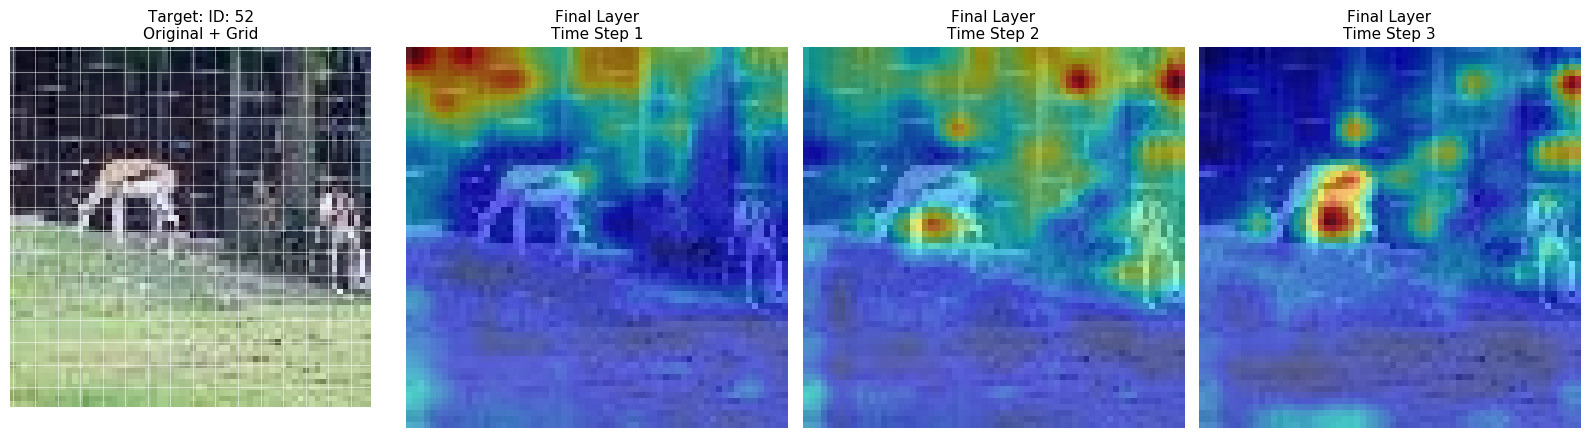

In [57]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn.functional as F
import numpy as np
import random

# ==========================================
# 1. Setup & Random Image Selection
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# Pick a fresh random image
random_idx = random.randint(0, len(val_loader.dataset) - 1)
img, label = val_loader.dataset[random_idx]
class_name = val_loader.dataset.classes[label] if hasattr(val_loader.dataset, 'classes') else f"ID: {label}"

img_t = img.unsqueeze(0).to(device)
h, w = img_t.shape[-2], img_t.shape[-1]

# Denormalize image
display_img = (img_t[0].cpu().permute(1, 2, 0).numpy() - img_t.min().item()) / (img_t.max().item() - img_t.min().item())

# ==========================================
# 2. Layout: 1 Row for all Time Steps
# ==========================================
# Columns: 1 (Original Image) + model.T (Final Layer Heatmaps)
num_cols = 1 + model.T
fig = plt.figure(figsize=(num_cols * 4, 5))
gs = gridspec.GridSpec(1, num_cols, figure=fig)

# --- Col 0: Original Image with Grid ---
with torch.no_grad():
    x_tokens = model.patch_embed(img_t)
    n_patches = x_tokens.shape[1]
    grid_size = int(np.sqrt(n_patches))

ax_img = fig.add_subplot(gs[0, 0])
ax_img.imshow(display_img)
# Visual patch grid
step = h // grid_size
for i in range(0, w + 1, step): ax_img.axvline(i, color='white', lw=0.8, alpha=0.5)
for i in range(0, h + 1, step): ax_img.axhline(i, color='white', lw=0.8, alpha=0.5)
ax_img.set_title(f"Target: {class_name}\nOriginal + Grid", fontsize=11)
ax_img.axis('off')

# ==========================================
# 3. Forward Pass & Matrix Capture
# ==========================================
with torch.no_grad():
    y = model.y_0.expand(1, -1, -1)
    z = model.z_0.expand(1, -1, -1)
    
    for t in range(model.T):
        # Run through Memory updates
        for m in range(model.M):
            for l, block in enumerate(model.blocks):
                seq_inner = torch.cat([x_tokens, y, z], dim=1)
                seq_inner, attn = forward_with_attention(block, seq_inner, model.sin_table, model.cos_table)
                
                # PLOT CONDITION: Final Memory Step (M) AND Final Layer (L)
                if m == model.M - 1 and l == model.L - 1:
                    ax = fig.add_subplot(gs[0, t + 1])
                    
                    mean_attn = attn[0].mean(0).cpu().numpy()
                    y_map = mean_attn[n_patches, :n_patches].reshape(grid_size, grid_size)
                    
                    # Upsample heatmap
                    heatmap = F.interpolate(
                        torch.tensor(y_map).view(1, 1, grid_size, grid_size),
                        size=(h, w), mode='bilinear'
                    ).squeeze().numpy()
                    
                    ax.imshow(display_img)
                    ax.imshow(heatmap, cmap='jet', alpha=0.55)
                    ax.set_title(f"Final Layer\nTime Step {t+1}", fontsize=11)
                    ax.axis('off')

                z = seq_inner[:, -model.K:, :]
        
        # Outer y Update (Recurrence)
        seq_outer = torch.cat([y, z], dim=1)
        outer_n = 1 + model.K
        seq_outer, _ = forward_with_attention(model.blocks[0], seq_outer, 
                                             model.sin_table[:, :, :outer_n, :], 
                                             model.cos_table[:, :, :outer_n, :])
        y = seq_outer[:, 0:1, :]

plt.tight_layout()
plt.show()